# Distillation by metrics — reasoning evals (with synthetic-trace baselines)

Plots `summary_reasoning_evals.json` results for the `distillation_by_metrics`
group, one graph per model (currently `qwen_3b`).

Each metric-driven curve is one experiment (e.g. `entropy_gain`), showing accuracy
as training progresses. For context, three baseline curves from the
`distillation_on_synthetic_traces` group are overlaid on the same figure for the
matching model and dataset: `direct_reasoning_trace`, `distill_w_explained`, and
`corrected_answer`. Baselines are drawn dashed and semi-transparent so they are
visually distinct from the metric-driven runs.

The **X axis is "training samples seen"**, not epochs: the two groups consume very
different amounts of data per epoch, so each curve's epoch is multiplied by its
samples-per-epoch — 1024 for `distillation_by_metrics` (top-k resampled per epoch)
and 9626 for the full-dataset baselines. This compares the runs at an equal data
budget. The metric-driven curve therefore sits in the far-left (low-sample) region
of the axis — that compression is the point: it reaches comparable accuracy with an
order of magnitude less data.

Epoch 0 is the base model evaluated with chain-of-thought, taken from the
synthetic-traces group (`base_model/<model>_cot/...`) because the by-metrics group
has no `base_model` folder of its own. It anchors every curve at x=0 and is drawn as
a dashed gray reference line. Experiments / models / datasets are discovered from the
directory tree, so re-running picks up newly finished runs (e.g. a future
`student_entropy` variant) automatically. To analyze another group, copy this
notebook and change `GROUP_NAME`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

from core.utils.graph_style import set_style

set_style()

GROUP_NAME = "distillation_by_metrics"
BASELINE_GROUP = "distillation_on_synthetic_traces"  # source of the overlay baselines + base anchor
BASELINE_EXPERIMENTS = ("direct_reasoning_trace", "distill_w_explained", "corrected_answer")
SUMMARY_FILENAME = "summary_reasoning_evals.json"
BASE_EXPERIMENT = "base_model"
BASE_SUFFIX = "_cot"  # use the *_cot base_model folders for epoch 0
METRIC = "accuracy"
SAMPLES_PER_EPOCH = 1024  # distillation_by_metrics: top-k examples resampled per epoch
BASELINE_SAMPLES_PER_EPOCH = 9626  # synthetic-trace baselines: full dataset per epoch
SAVE = True  # also write PNGs under artifacts/<group>/<dataset>/plots/


def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk up from `start` (cwd by default) until an `artifacts/` dir is found."""
    start = (start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "artifacts").is_dir():
            return d / "artifacts"
    raise FileNotFoundError("artifacts/ not found above cwd")


ARTIFACTS = find_artifacts_dir()
GROUP_DIR = ARTIFACTS / GROUP_NAME
BASELINE_GROUP_DIR = ARTIFACTS / BASELINE_GROUP
GROUP_DIR

PosixPath('/Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_by_metrics')

In [2]:
def load_curves(dataset_dir: Path) -> dict:
    """model -> experiment -> eval_key -> sorted [(epoch, metric)].

    Skips the base_model folder and any model dir without a finished summary.
    """
    data: dict = {}
    for exp_dir in sorted(dataset_dir.iterdir()):
        if not exp_dir.is_dir() or exp_dir.name == BASE_EXPERIMENT:
            continue
        for model_dir in sorted(exp_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            summary = model_dir / SUMMARY_FILENAME
            if not summary.is_file():
                continue  # training not finished yet
            content = json.loads(summary.read_text())
            for eval_key, records in content.items():
                points = sorted(
                    (r["epoch"], r[METRIC])
                    for r in records
                    if r.get("epoch") is not None and r.get(METRIC) is not None
                )
                data.setdefault(model_dir.name, {}).setdefault(exp_dir.name, {})[eval_key] = points
    return data


def load_base(dataset_dir: Path, model: str) -> dict:
    """eval_key -> epoch-0 accuracy from the *_cot base_model folder."""
    out: dict = {}
    base_dir = dataset_dir / BASE_EXPERIMENT / f"{model}{BASE_SUFFIX}"
    if base_dir.is_dir():
        for results in sorted(base_dir.glob("*/results.json")):
            out[results.parent.name] = json.loads(results.read_text())[METRIC]
    return out

In [3]:
# Baselines come from a different group and consume the full 9626-row dataset per
# epoch, vs. 1024 resampled per epoch for distillation_by_metrics. They are drawn
# dashed / semi-transparent / behind the metric-driven curves so the two families
# are easy to tell apart.
BASELINE_KW = dict(linestyle="--", alpha=0.55, linewidth=1.6, zorder=1)


def load_baseline_curves(dataset: str) -> dict:
    """Baseline-group curves for `dataset`, restricted to BASELINE_EXPERIMENTS.

    Same shape as load_curves (model -> experiment -> eval_key -> points).
    Empty if the baseline dataset is absent.
    """
    baseline_dataset_dir = BASELINE_GROUP_DIR / dataset
    if not baseline_dataset_dir.is_dir():
        return {}
    out: dict = {}
    for model, exps in load_curves(baseline_dataset_dir).items():
        kept = {e: pts for e, pts in exps.items() if e in BASELINE_EXPERIMENTS}
        if kept:
            out[model] = kept
    return out


def plot_curve(ax, points, base, eval_key, samples_per_epoch, label, **kw):
    """Plot one (epoch, metric) curve on the *training-samples-seen* X axis.

    Prepends the epoch-0 base anchor when available, then converts every epoch to
    cumulative samples via `epoch * samples_per_epoch` (epoch 0 -> x=0).
    """
    xs = [e for e, _ in points]
    ys = [v for _, v in points]
    if eval_key in base:  # anchor every curve at the epoch-0 base
        xs = [0.0] + xs
        ys = [base[eval_key]] + ys
    xs = [e * samples_per_epoch for e in xs]
    ax.plot(xs, ys, label=label, **kw)

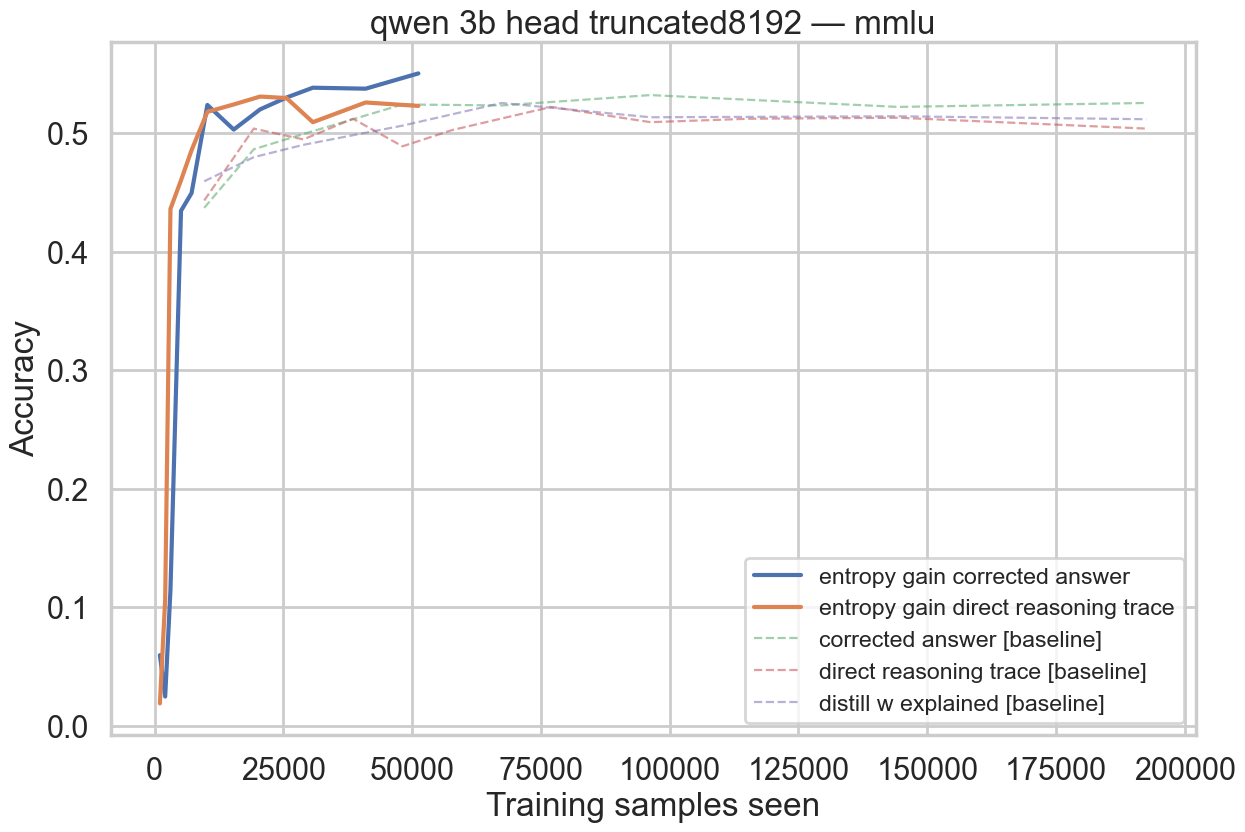

In [4]:
datasets = sorted(p.name for p in GROUP_DIR.iterdir() if p.is_dir())

for dataset in datasets:
    dataset_dir = GROUP_DIR / dataset
    curves = load_curves(dataset_dir)  # by-metrics runs drive which figures exist
    baseline_curves = load_baseline_curves(dataset)  # synthetic-trace overlays

    for model in sorted(curves):
        # base anchor comes from the baseline group (by-metrics has no base_model)
        base = load_base(BASELINE_GROUP_DIR / dataset, model)
        eval_keys = {key for exp in curves[model].values() for key in exp}
        eval_keys |= {key for exp in baseline_curves.get(model, {}).values() for key in exp}
        multi = len(eval_keys) > 1  # disambiguate labels only if needed

        fig, ax = plt.subplots(figsize=(14, 9))

        # metric-driven curves (distillation_by_metrics) — solid, full color
        for experiment in sorted(curves[model]):
            for eval_key, points in curves[model][experiment].items():
                label = experiment.replace("_", " ")
                if multi:
                    label = f"{label} [{eval_key}]"
                plot_curve(ax, points, base, eval_key, SAMPLES_PER_EPOCH, label)

        # baseline curves (distillation_on_synthetic_traces) — dashed, faded
        for experiment in sorted(baseline_curves.get(model, {})):
            for eval_key, points in baseline_curves[model][experiment].items():
                label = f"{experiment.replace('_', ' ')} [baseline]"
                if multi:
                    label = f"{label} [{eval_key}]"
                plot_curve(ax, points, base, eval_key, BASELINE_SAMPLES_PER_EPOCH, label, **BASELINE_KW)

        for eval_key, acc in base.items():  # base reference line(s)
            ref_label = "base model (CoT)" + (f" [{eval_key}]" if multi else "")
            ax.axhline(acc, ls="--", color="gray", alpha=0.7, label=ref_label)

        ax.set_title(f"{model.replace('_', ' ')} — {dataset}")
        ax.set_xlabel("Training samples seen")
        ax.set_ylabel(METRIC.capitalize())
        ax.legend(fontsize="x-small", loc="best")

        if SAVE:
            plots_dir = dataset_dir / "plots"
            plots_dir.mkdir(parents=True, exist_ok=True)
            fig.savefig(
                plots_dir / f"{model}_reasoning_evals.png",
                bbox_inches="tight",
                dpi=150,
            )

        plt.show()